In [1]:
include("Fun.jl")
include("CRD_STA.jl")
using NonlinearEigenproblems
using Plots
using Interpolations

In [2]:
const Float = Float64
const ComplexF = ComplexF64
const EigenResult = GeneralizedEigen{ComplexF, ComplexF, Matrix{ComplexF}, Vector{ComplexF}}
struct SimulationParams
    # 输入参数
    N_cheb::Int
    Mr::Float
    gamma::Float
    sigma::Float
    Ro::Float
    Tw::Float
    
    # 计算参数
    Co::Float
    
    # 基础流变量
    u0::Vector{Float}
    v0::Vector{Float}
    w0::Vector{Float}
    f::Vector{Float}
    q::Vector{Float}
    D::Matrix{Float}
    D2::Matrix{Float}
    x::Matrix{Float}
    
    # 核心矩阵
    F::Matrix{Float}
    G::Matrix{Float}
    H::Matrix{Float}
    T::Matrix{Float}
    
    # 物理场向量
    rho::Matrix{Float}
    lam::Matrix{Float}
    kappa::Matrix{Float}
   function SimulationParams(N_cheb::Int, Mr::Float, gamma::Float, sigma::Float, Ro::Float, Tw::Float)
        # 计算不变值
        Co = 2 - Ro - Ro^2
        
        # 计算基础流 (假设这些函数已定义)
        u0, v0, w0, f, q, D, D2, x = baseflow_var(N_cheb, Ro, "cheb")
        
        # 计算温度和焓场 (假设T_ca函数已定义)
        H_mat, T_mat = T_ca(Mr, f, q, w0, gamma, Tw)
        
        # 插值计算 (假设interp函数已定义)
        F_mat, G_mat, H_mat, T_mat, rho, z = interp(u0, v0, H_mat, T_mat, x, N_cheb, "sim")
        
        # 计算粘性系数
        lam = - (2/3) .* T_mat
        kappa = (1/sigma) .* T_mat
        
        # 创建并返回结构体
        new(N_cheb, Mr, gamma, sigma, Ro, Tw, Co, 
            u0, v0, w0, f, q, D, D2, x,
            F_mat, G_mat, H_mat, T_mat,
            rho, lam, kappa)
        end
end
function setup_simulation(N_cheb, Mr, gamma, sigma, Ro, Tw)
    return SimulationParams(N_cheb, Mr, gamma, sigma, Ro, Tw)
end
function BaseFlow(N_cheb,Mr,gamma,sigma,Ro,Tw)
    params = setup_simulation(N_cheb,Mr,gamma,sigma,Ro,Tw)
    const_params = (
    params.F, params.G, params.H, params.rho, params.lam, params.kappa, params.D,
    params.D2,params.T, params.sigma, params.gamma, params.N_cheb, params.Ro, params.Co
    )
    return params,const_params
end


BaseFlow (generic function with 1 method)

In [48]:
function eigenpro(R, Ma, al, be, const_params)
    F, G, H, rho, lam, kappa, D, D2,T, sigma, gamma, N_cheb, Ro, Co = const_params
    B0, B1 = Timemode(F, G, H, rho, lam, kappa, T, sigma, gamma, R, Ma, al, be, N_cheb, Ro, Co,D ,D2)
    return B0,B1
end
function eigensolve(B0,B1)
    return eigen(B0,B1)
end
function selectdval(C,re_max)
    return filter(x->-0.05<imag(x)<0.05&&abs(real(x))<re_max,C.values)
end
function pinpoint(R,be,total,alpha,step)
    pinpoints = Matrix{Complex}(undef,0,4)

    for i = 1 : size(total,2)  

        d2 = diff1(real(total[:,i]),0.001)

        for j = 1 : length(d2)-1

            if d2[j] * d2[j+1] < 0 && abs(d2[j+1])<0.01
                pinpoints = [pinpoints;[R alpha[j+1] be total[j+1,i]]]

            end

        end
    end
    return pinpoints
end
function ali_range(R,ali,re_max,Mr,be,const_params)
    total = []
    Ma = Mr/R
    al_all =  Matrix{Complex}(undef,0,1)
    al = complex(0.2,ali)
    B0,B1 = eigenpro(R, Ma, al, be, const_params)
    C = eigensolve(B0,B1)
    val = selectdval(C,re_max)
        for i = 1 : min(2,length(val))
            indi = []
            val_temp = val[i]
            vec = eigvector(val[i],C.values,C.vectors)

            for alr in range(0.2,0.5,step=0.002)
                al = complex(alr,ali)
                B0,B1 = eigenpro(R, Ma, al, be, const_params)
                val0,vec0 = RQI(B0,B1,val_temp,q0 = vec)
                indi = [indi;val0]
                al_all = [al_all;al]
                val_temp = val0
                vec = vec0 
            end
            if i == 1
                total = indi
            else
                total = [total indi]
            end
        end
    return total,al_all
end
function acceleration_ali(data_all)
    if isreal(data_all[end,3]) 
        step = 0.01
    else 
        step = 0.002
    end
    step = 0.002
    return step
end
function acceleration_R(data_all,Ro)
    if Ro == 1
        if data_all[end,6] < -0.0015
            step = 0.5
        else
            step = 0.15
        end
    else
        if data_all[end,6] < -0.001
            step = 3
        elseif  -0.001 < data_all[end,6] < -0.0005
            step = 3
        elseif  -0.0005 < data_all[end,6] < -0.0002
            step = 1
        else
            if abs(data_all[end, 1] - data_all[end-1, 1]) < 1e-6
                step = 0.15
            else
                step = 1
            end
        end
    end
    return step
end

acceleration_R (generic function with 1 method)

In [77]:
function caculate(beta,const_params, Tw,Mr,Ro)
    dataall = Matrix{Float}(undef,0,6)
    re_max = 0.5
    data_all = Matrix{Complex}(undef,0,4)
    backstep = 2

    if Ro == 1
        ali_ref = 0.1
    else
        ali_ref = 0.26 - (Tw - 1) * 0.16
    end
    for be in beta

        while true
            data_all = Matrix{Complex}(undef,0,4)
            data =  Matrix{Complex}(undef,0,4)
            data_1 = data_all = Matrix{Complex}(undef,0,4)
            if Ro == 1
                if size(dataall,1) != 0
                    R = max(dataall[end,1] - backstep , 20)
                else
                    R = 22
                end
            else
                R = 240
                val = 0
                while imag(val[1])>-0.01
                    R -= 10
                    Ma = Mr/R
                    al = complex(0.2,ali_ref)
                    B0,B1 = eigenpro(R, Ma, al, be, const_params)
                    val = selectdval(eigensolve(B0,B1),re_max)
                end
            end

            while true 
                total,al_all = ali_range(R,ali_ref,re_max,Mr,be,const_params)
                PinPoint = pinpoint(R,be,total,al_all,0.001)
                if size(PinPoint,1) == 0
                    ali_ref += 0.002
                    writedlm("AS.dat",ali_ref)
                    continue

                else
                    data_all = [data_all;[R be PinPoint[findmax(imag(PinPoint[:,4]))[2],2] PinPoint[findmax(imag(PinPoint[:,4]))[2],4]]]
                    data_1 = [data_1;[R be PinPoint[findmax(imag(PinPoint[:,4]))[2],2] PinPoint[findmax(imag(PinPoint[:,4]))[2],4]]]
                end

                writedlm("AS.dat",data_all)
                
                if (length(axes(data_1,1)) > 2 && imag(data_1[end - 1,4])>imag(data_1[end-2,4])&&imag(data_1[end-1,4])>imag(data_1[end,4]) && imag(data_1[end - 1,4]) != 0)
                    break
                end
                step_ali = acceleration_ali(data_all)
                ali_ref += step_ali

            end
            #section2
            ali = imag(data_all[end - 1,3])
            R0 = real(data_all[end - 1,1])
            fill!(data_all,0)
            data1 =  Matrix{Complex}(undef,0,4)
            while true
                Ma = Mr/R
                al = complex(0.2,ali)
                B0,B1 = eigenpro(R, Ma, al, be, const_params)
                C = eigensolve(B0,B1)
                val = selectdval(C,re_max)
                total,al_all = ali_range(R,ali,re_max,Mr,be,const_params)
                PinPoint = pinpoint(R,be,total,al_all,0.001)

                if size(PinPoint,1) == 0
                    R += 0.15
                    continue
                else
                    data_temp = [R be PinPoint[findmax(imag(PinPoint[:,4]))[2],2] PinPoint[findmax(imag(PinPoint[:,4]))[2],4]]
                end
                data1 = [data1;data_temp]
                data_all = [real(data1[:,1]) real(data1[:,2]) real(data1[:,3]) imag(data1[:,3]) real(data1[:,4]) imag(data1[:,4])]
                writedlm("AS1.dat",data_all)
                if (data_all[end,6]>-1e-4)
                    dataall = [dataall;data_all[end:end,:]]
                end
                if (data_all[end,6]>-1e-4) || (size(data_all,1) > 2 && (data_all[end,6] < data_all[end-1,6]) && (data_all[end-1,6]>data_all[end-2,6]))  
                    break
                end
                step_R = acceleration_R(data_all,Ro)

                if be < -0.35
                    R += 5*step_R
                else
                    R += step_R
                end
            end
            if (data_all[end,6]>-1e-4) 
                # re_max = abs(real(dataall[end,5])) + 0.03
                ali_ref = real(dataall[end,4]) - 0.01
                writedlm("Tw=$(Tw)_Ma=$(Mr)_Ro=$(Ro).dat",dataall)
                backstep = 1
                break
            else 
                ali_ref -= 0.012
                backstep -= 0.4
            end

        end
    end
end    

caculate (generic function with 1 method)

In [78]:
N_cheb = 59
Mr = 0.9
gamma = 1.4
sigma = 0.72
Ro = 1.0
for Tw in range(0.9,1.2,step=0.1)
    params,const_params = BaseFlow(N_cheb, Mr, gamma, sigma, Ro, Tw)
    beta = range(-0.21,-0.25,step = - 0.01)
    caculate(beta,const_params,Tw,Mr,Ro) 
end 

In [82]:
Mr = 0.9
Ro = 1.0
for Tw = 0.8 : 0.1 : 1.2
    a1 = readdlm("Tw=$(Tw)_Ma=$(Mr)_Ro=$(Ro)_part.dat")
    k = 2                      
    p = sortperm(a1[:, k])   
    a1 = a1[p, :]  
    writedlm("Tw=$(Tw)_Ma=$(Mr)_Ro=$(Ro)_part.dat",a1)
    x = a1[:,2]
    y = a1[:,1] 
    function sort_unique_xy(x::AbstractVector, y::AbstractVector)
        @assert length(x) == length(y) "x,y 长度不一致"
        p = sortperm(x)
        xs, ys = x[p], y[p]
        # 去掉重复 x（保留第一次出现）
        keep = [true; diff(xs) .> 0]
        return xs[keep], ys[keep]
    end
    xs, ys = sort_unique_xy(x, y)
    function smooth_moving_avg(ys; w)
        @assert isodd(w) "窗口 w 请设为奇数"
        r = (w-1)÷2
        ys = similar(y, Float64)
        for i in eachindex(y)
            lo = max(firstindex(y), i-r)
            hi = min(lastindex(y),  i+r)
            ys[i] = Statistics.mean(@view y[lo:hi])
        end
        return ys
    end
    y_ma = smooth_moving_avg(y; w= eleven=5)  # 写法示例：w=11
    all = [x y_ma]  
    writedlm("Tw=$(Tw)_Ma=$(Mr)_Ro=$(Ro)_interp.dat",all)
end

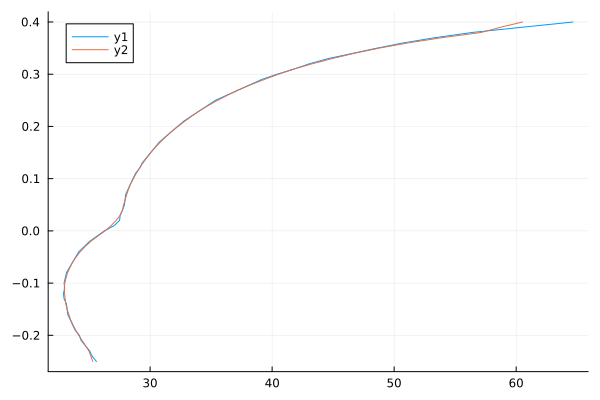

In [83]:
plot(y , x)
plot!(y_ma,x)